--- Continent Totals (Descending) ---
{'Europe': 47622, 'South America': 25125, 'Asia': 23519, 'North America': 11731, 'Oceania': 5823, 'Africa': 4351, 'Antarctica': 0}

--- Continent Colors (Darkest to Lightest) ---
{'Europe': '#7F0000', 'South America': '#B30000', 'Asia': '#E60000', 'North America': '#FF3333', 'Oceania': '#FF6666', 'Africa': '#FF9999', 'Antarctica': '#FFCCCC'}
{'Europe': 47622, 'South America': 25125, 'Asia': 23519, 'North America': 11731, 'Oceania': 5823, 'Africa': 4351, 'Antarctica': 0}
the next continent is
{'Europe': '#7F0000', 'South America': '#B30000', 'Asia': '#E60000', 'North America': '#FF3333', 'Oceania': '#FF6666', 'Africa': '#FF9999', 'Antarctica': '#FFCCCC'}


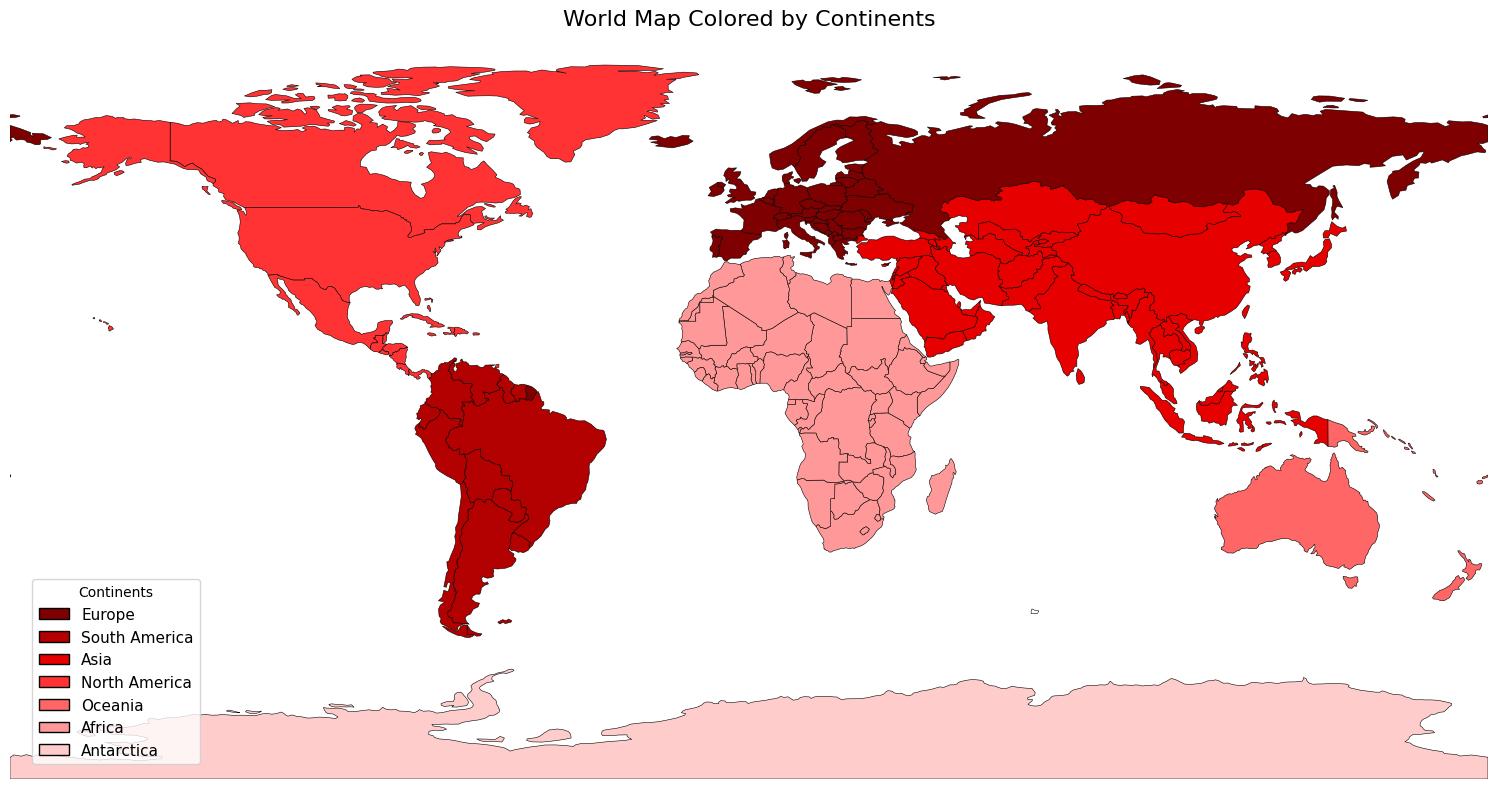

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def get_recipe_data():
    # Local region data
    region_recipes = {
        "Australian": 5823, "Belgian": 1060, "Canadian": 6700, "Caribbean": 3026,
        "Central American": 460, "Chinese and Mongolian": 5896, "Deutschland": 4323,
        "Eastern European": 2503, "French": 6381, "Greek": 4185, "Indian Subcontinent": 6464,
        "Irish": 2532, "Italian": 16582, "Japanese": 2041, "Korean": 668,
        "Mexican": 14463, "Middle Eastern": 3905, "Northern Africa": 1611,
        "Rest Africa": 2740, "Scandinavian": 2811, "South American": 7176,
        "Southeast Asian": 1940, "Spanish and Portuguese": 2844, "Thai": 2605,
        "UK": 4401, "US": 5031
    }

    # Updated mapping to include Oceania and Antarctica
    continent_regions = {
        "Africa": ["Northern Africa", "Rest Africa"],
        "Asia": ["Chinese and Mongolian", "Indian Subcontinent", "Japanese", "Korean", "Middle Eastern", "Southeast Asian", "Thai"],
        "Oceania": ["Australian"],
        "Europe": ["Belgian", "Deutschland", "Eastern European", "French", "Greek", "Irish", "Italian", "Scandinavian", "Spanish and Portuguese", "UK"],
        "South America": ["Caribbean", "Central American", "Mexican", "South American"],
        "North America": ["Canadian", "US"],
        "Antarctica": [] # No regions listed in your data
    }

    # 1. Calculate Continent Totals
    continent_totals = {}
    for continent, regions in continent_regions.items():
        continent_totals[continent] = sum(region_recipes.get(r, 0) for r in regions)

    # 2. Sort by value descending
    sorted_data = sorted(continent_totals.items(), key=lambda x: x[1], reverse=True)

    # 3. Define 7-step Red Gradient (Darkest to Lightest)
    red_shades = [
        "#7F0000", # Rank 1 (Darkest)
        "#B30000", # Rank 2
        "#E60000", # Rank 3
        "#FF3333", # Rank 4
        "#FF6666", # Rank 5
        "#FF9999", # Rank 6
        "#FFCCCC"  # Rank 7 (Lightest)
    ]

    # 4. Construct sorted dictionaries
    sorted_totals_dict = {}
    sorted_colors_dict = {}

    for i, (name, total) in enumerate(sorted_data):
        sorted_totals_dict[name] = total
        sorted_colors_dict[name] = red_shades[i]

    # 5. Output
    print("--- Continent Totals (Descending) ---")
    print(sorted_totals_dict)

    print("\n--- Continent Colors (Darkest to Lightest) ---")
    print(sorted_colors_dict)

    return sorted_totals_dict, sorted_colors_dict

# Run the function
totals, colors = get_recipe_data()
print(totals)
print("the next continent is")
print(colors)

# Load shapefile
shapefile_path = "ne_110m_admin_0_countries.shp"
world = gpd.read_file(shapefile_path)
continent_colors = colors

# Create color column for each country based on continent
world["color"] = world["CONTINENT"].map(continent_colors).fillna("#FFFFFF")

# Wide landscape figure - direct matplotlib (no cartopy aspect constraints)
fig, ax = plt.subplots(figsize=(20, 8))
ax.set_facecolor("#eefbff")  # Ocean color
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_aspect('auto')  # Force stretch to fill figure

# Plot countries
world.plot(ax=ax, color=world["color"], edgecolor="black", linewidth=0.4)

# Title
ax.set_title("World Map Colored by Continents", fontsize=16, pad=10)
ax.axis('off')

# Legend
legend_elements = [
    Patch(facecolor=color, edgecolor="black", label=continent)
    for continent, color in continent_colors.items()
]
ax.legend(
    handles=legend_elements,
    loc="lower left",
    title="Continents",
    frameon=True,
    fontsize=11,
    bbox_to_anchor=(0.01, 0.01)
)
plt.tight_layout()
plt.show()

In [ ]:
def get_recipe_data():
    # Data defined locally within the function
    region_recipes = {
        "Australian": 5823, "Belgian": 1060, "Canadian": 6700, "Caribbean": 3026,
        "Central American": 460, "Chinese and Mongolian": 5896, "Deutschland": 4323,
        "Eastern European": 2503, "French": 6381, "Greek": 4185, "Indian Subcontinent": 6464,
        "Irish": 2532, "Italian": 16582, "Japanese": 2041, "Korean": 668,
        "Mexican": 14463, "Middle Eastern": 3905, "Northern Africa": 1611,
        "Rest Africa": 2740, "Scandinavian": 2811, "South American": 7176,
        "Southeast Asian": 1940, "Spanish and Portuguese": 2844, "Thai": 2605,
        "UK": 4401, "US": 5031
    }

    continent_regions = {
        "African": ["Northern Africa", "Rest Africa"],
        "Asian": ["Chinese and Mongolian", "Indian Subcontinent", "Japanese", "Korean", "Middle Eastern", "Southeast Asian", "Thai"],
        "Australasian": ["Australian"],
        "European": ["Belgian", "Deutschland", "Eastern European", "French", "Greek", "Irish", "Italian", "Scandinavian", "Spanish and Portuguese", "UK"],
        "Latin American": ["Caribbean", "Central American", "Mexican", "South American"],
        "North American": ["Canadian", "US"]
    }

    # 1. Calculate Continent Totals
    continent_totals = {}
    for continent, regions in continent_regions.items():
        continent_totals[continent] = sum(region_recipes.get(r, 0) for r in regions)

    # 2. Sort by value descending to determine order
    sorted_data = sorted(continent_totals.items(), key=lambda x: x[1], reverse=True)

    # 3. Define the Red Gradient (Darkest to Lightest)
    red_shades = ["#8b0000", "#b22222", "#ff0000", "#ff4d4d", "#ff9999", "#ffe5e5"]

    # 4. Construct sorted dictionaries
    sorted_totals_dict = {}
    sorted_colors_dict = {}

    for i, (name, total) in enumerate(sorted_data):
        sorted_totals_dict[name] = total
        sorted_colors_dict[name] = red_shades[i]

    # 5. Print both arrays (dictionaries)
    print("--- Continent Totals (Descending) ---")
    print(sorted_totals_dict)

    print("\n--- Continent Colors (Darkest to Lightest) ---")
    print(sorted_colors_dict)

    return sorted_totals_dict, sorted_colors_dict

# Execute the function
totals, colors = get_recipe_data()
print(colors)
print(totals)

--- Continent Totals (Descending) ---
{'European': 47622, 'Latin American': 25125, 'Asian': 23519, 'North American': 11731, 'Australasian': 5823, 'African': 4351}

--- Continent Colors (Darkest to Lightest) ---
{'European': '#8b0000', 'Latin American': '#b22222', 'Asian': '#ff0000', 'North American': '#ff4d4d', 'Australasian': '#ff9999', 'African': '#ffe5e5'}
{'European': '#8b0000', 'Latin American': '#b22222', 'Asian': '#ff0000', 'North American': '#ff4d4d', 'Australasian': '#ff9999', 'African': '#ffe5e5'}
{'European': 47622, 'Latin American': 25125, 'Asian': 23519, 'North American': 11731, 'Australasian': 5823, 'African': 4351}


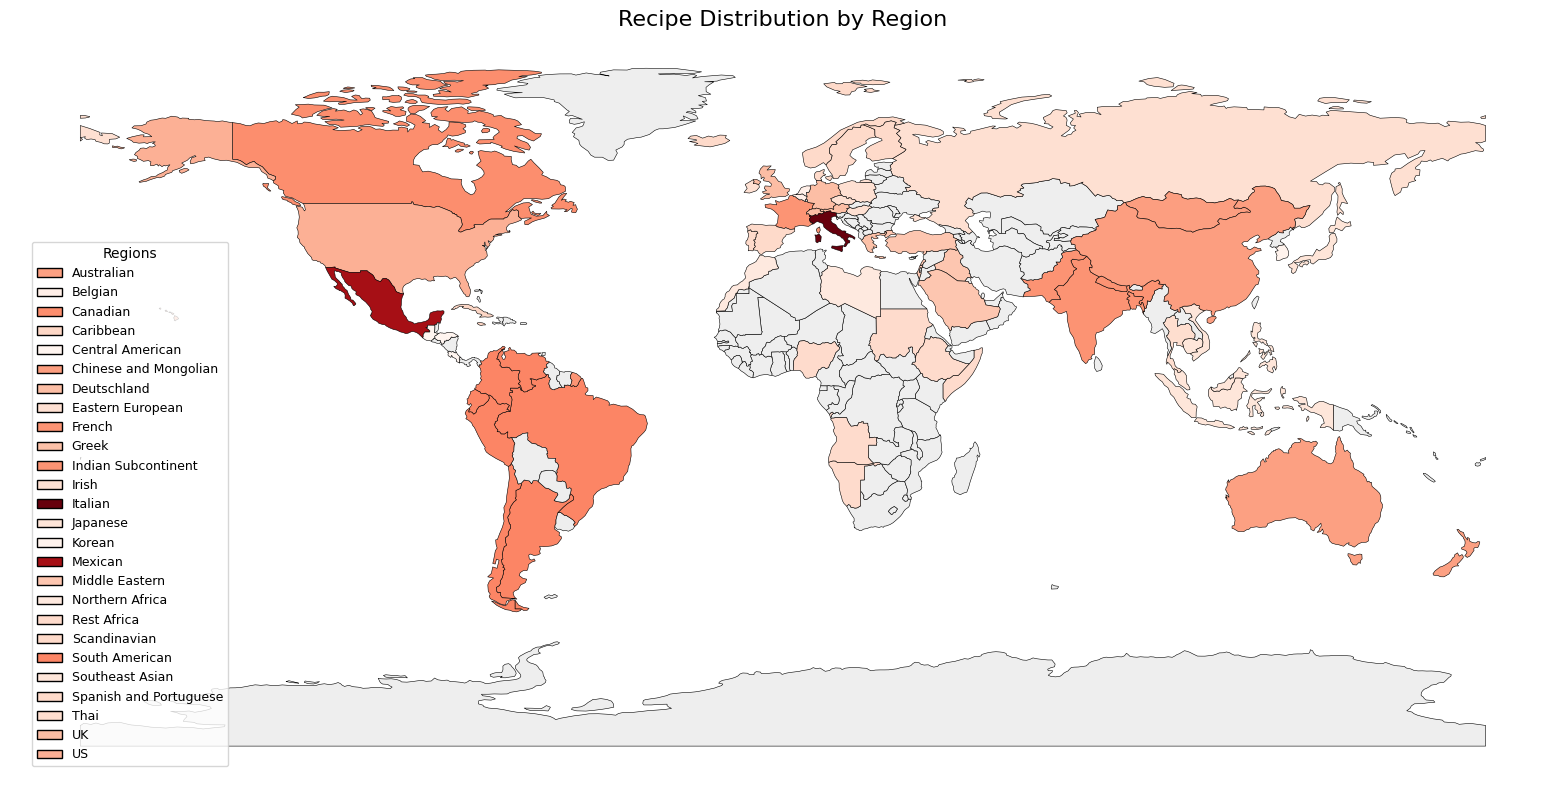

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# -----------------------------
# 1. Region Recipe Counts
# -----------------------------
region_recipes = {
    "Australian": 5823, "Belgian": 1060, "Canadian": 6700, "Caribbean": 3026,
    "Central American": 460, "Chinese and Mongolian": 5896, "Deutschland": 4323,
    "Eastern European": 2503, "French": 6381, "Greek": 4185, "Indian Subcontinent": 6464,
    "Irish": 2532, "Italian": 16582, "Japanese": 2041, "Korean": 668,
    "Mexican": 14463, "Middle Eastern": 3905, "Northern Africa": 1611,
    "Rest Africa": 2740, "Scandinavian": 2811, "South American": 7176,
    "Southeast Asian": 1940, "Spanish and Portuguese": 2844, "Thai": 2605,
    "UK": 4401, "US": 5031
}

# -----------------------------
# 2. Country → Region Mapping
# (From Table S2)
# -----------------------------
country_to_region = {

    # Europe
    "Italy": "Italian",
    "France": "French",
    "Germany": "Deutschland",
    "Austria": "Deutschland",
    "Switzerland": "Deutschland",
    "Spain": "Spanish and Portuguese",
    "Portugal": "Spanish and Portuguese",
    "United Kingdom": "UK",
    "Ireland": "Irish",
    "Greece": "Greek",
    "Belgium": "Belgian",
    "Netherlands": "Belgian",

    "Denmark": "Scandinavian",
    "Norway": "Scandinavian",
    "Sweden": "Scandinavian",
    "Finland": "Scandinavian",
    "Iceland": "Scandinavian",

    "Poland": "Eastern European",
    "Hungary": "Eastern European",
    "Czechia": "Eastern European",
    "Russia": "Eastern European",

    # Asia
    "India": "Indian Subcontinent",
    "Pakistan": "Indian Subcontinent",
    "Bangladesh": "Indian Subcontinent",
    "Nepal": "Indian Subcontinent",

    "China": "Chinese and Mongolian",
    "Mongolia": "Chinese and Mongolian",

    "Japan": "Japanese",
    "South Korea": "Korean",

    "Thailand": "Thai",

    "Cambodia": "Southeast Asian",
    "Vietnam": "Southeast Asian",
    "Malaysia": "Southeast Asian",
    "Indonesia": "Southeast Asian",
    "Philippines": "Southeast Asian",

    "Turkey": "Middle Eastern",
    "Saudi Arabia": "Middle Eastern",
    "Lebanon": "Middle Eastern",
    "Israel": "Middle Eastern",
    "Iraq": "Middle Eastern",

    # Africa
    "Morocco": "Northern Africa",
    "Libya": "Northern Africa",

    "Nigeria": "Rest Africa",
    "Ethiopia": "Rest Africa",
    "Angola": "Rest Africa",
    "Namibia": "Rest Africa",
    "Sudan": "Rest Africa",
    "Somalia": "Rest Africa",

    # Americas
    "Mexico": "Mexican",

    "Brazil": "South American",
    "Argentina": "South American",
    "Chile": "South American",
    "Peru": "South American",
    "Colombia": "South American",
    "Venezuela": "South American",
    "Ecuador": "South American",

    "Costa Rica": "Central American",
    "Guatemala": "Central American",
    "Honduras": "Central American",

    "Cuba": "Caribbean",
    "Jamaica": "Caribbean",

    # North America
    "Canada": "Canadian",
    "United States of America": "US",

    # Oceania
    "Australia": "Australian",
    "New Zealand": "Australian"
}

# -----------------------------
# 3. Generate Color Gradient
# -----------------------------
values = list(region_recipes.values())

norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
cmap = cm.Reds

region_colors = {
    region: mcolors.to_hex(cmap(norm(value)))
    for region, value in region_recipes.items()
}

# -----------------------------
# 4. Load World Map
# -----------------------------
shapefile_path = "ne_110m_admin_0_countries.shp"
world = gpd.read_file(shapefile_path)

# Assign region to each country
world["region"] = world["NAME"].map(country_to_region)

# Assign color
world["color"] = world["region"].map(region_colors).fillna("#eeeeee")

# -----------------------------
# 5. Plot Map
# -----------------------------
fig, ax = plt.subplots(figsize=(20,8))

ax.set_facecolor("#eefbff")

world.plot(
    ax=ax,
    color=world["color"],
    edgecolor="black",
    linewidth=0.4
)

ax.set_title("Recipe Distribution by Region", fontsize=16)
ax.axis("off")

# -----------------------------
# 6. Legend
# -----------------------------
legend_elements = [
    Patch(facecolor=color, edgecolor="black", label=region)
    for region, color in region_colors.items()
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    title="Regions",
    frameon=True,
    fontsize=9,
    bbox_to_anchor=(0.01,0.01)
)

plt.tight_layout()
plt.show()